# 07 — Unsupervised Clustering

Identify recurring **operational regimes** (load profiles) of the campus.
Two approaches:
1. **K-Means** — partition into k well-defined clusters
2. **DBSCAN** — density-based, naturally identifies anomalies as label −1

**Methodological improvements vs. the original code:**
- k chosen via the **elbow method** (not arbitrarily set to 4)
- DBSCAN's `eps` chosen via the **k-distance graph** (not by manual trial)
- More features included (not only 2D — 2D is just for visualization)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

DATA_PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
df_ml = pd.read_csv(DATA_PROCESSED / 'dataset_smart_campus_master.csv')
print(f"Loaded ML-ready dataset: {df_ml.shape}")


Loaded ML-ready dataset: (8783, 10)


## 1. K-Means — find optimal k via the elbow method

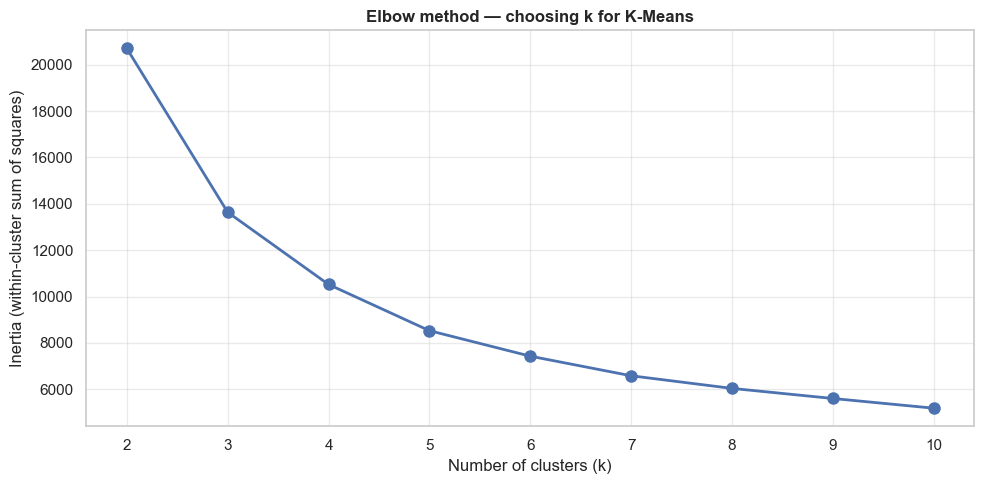

Selected k = 4 (elbow location).


In [9]:
# 1. Asegurarnos de que el Timestamp es formato fecha
df_ml['Timestamp'] = pd.to_datetime(df_ml['Timestamp'])

# 2. Extraer la hora como un número (0-23)
df_ml['Hora_Dia'] = df_ml['Timestamp'].dt.hour

# 3. Usar 'Hora_Dia' en lugar de 'Timestamp' en la lista de variables
features_cluster = ['Consumo_kWh', 'Ocupacion_Simulada', 'Hora_Dia', 'Temperatura']
X_cluster = df_ml[features_cluster].copy()

# 4. Ahora sí, a escalar sin problemas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inercias = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, inercias, marker='o', linewidth=2, markersize=8)
ax.set_title("Elbow method — choosing k for K-Means", fontweight='bold')
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / 'kmeans_elbow.png', dpi=120)
plt.show()

# Pick k where the curve flattens (typically 4)
K_OPTIMO = 4
print(f"Selected k = {K_OPTIMO} (elbow location).")

## 2. K-Means with the chosen k

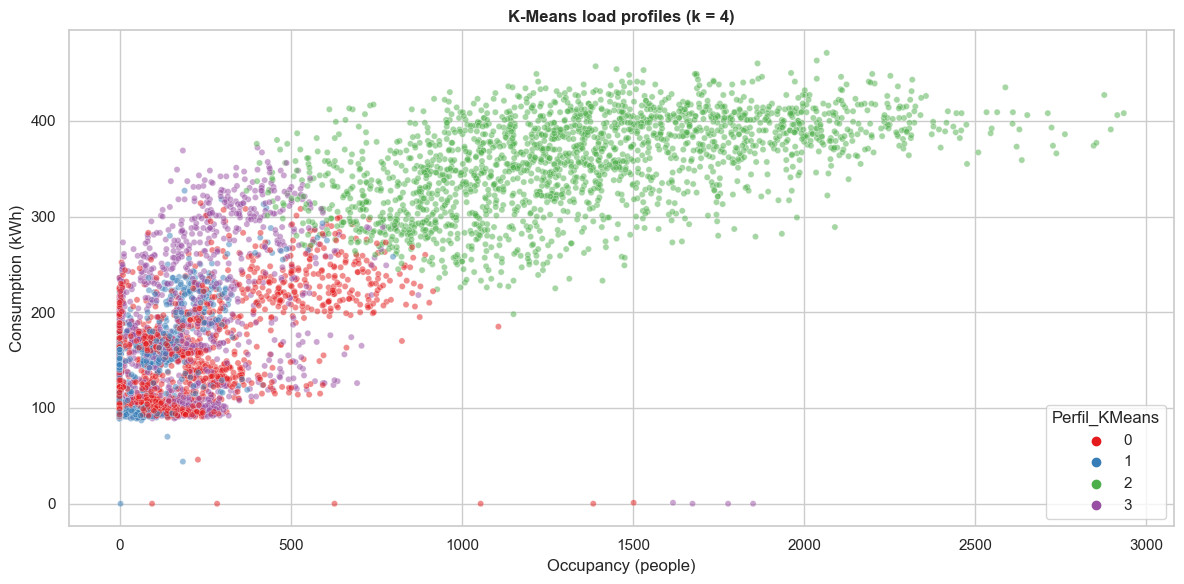


Mean profile per cluster:
               Consumo_kWh  Ocupacion_Simulada  Hora_Dia  Temperatura
Perfil_KMeans                                                        
0                   142.42              173.96     19.75        15.96
1                   114.19               28.64      4.38        13.10
2                   357.63             1356.57     14.28        17.98
3                   147.17              136.50     10.64        24.95


In [10]:
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_ml['Perfil_KMeans'] = kmeans.fit_predict(X_scaled)

# Visualize on the (occupancy, consumption) plane
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=df_ml, x='Ocupacion_Simulada', y='Consumo_kWh',
    hue='Perfil_KMeans', palette='Set1', alpha=0.5, s=20, ax=ax
)
ax.set_title(f"K-Means load profiles (k = {K_OPTIMO})", fontweight='bold')
ax.set_xlabel("Occupancy (people)")
ax.set_ylabel("Consumption (kWh)")
plt.tight_layout()
plt.savefig(FIGURES / 'kmeans_clusters.png', dpi=120)
plt.show()

# Profile statistics
print("\nMean profile per cluster:")
print(df_ml.groupby('Perfil_KMeans')[features_cluster].mean().round(2))


In [11]:
import plotly.express as px

# 1. Asegurar que el clúster se trata como categoría (texto), no como número continuo
df_ml['Clúster'] = df_ml['Perfil_KMeans'].astype(str)

# 2. Crear el gráfico 3D interactivo
fig = px.scatter_3d(
    df_ml,
    x='Ocupacion_Simulada', 
    y='Temperatura',       
    z='Consumo_kWh',        
    color='Clúster',        
    hover_data=['Temperatura'], # ¡Magia! Muestra la temperatura al pasar el ratón
    title='Perfiles de Carga K-Means en 3D (Interactivo)',
    color_discrete_sequence=px.colors.qualitative.Set1,
    opacity=0.7
)

# 3. Pulir el diseño (tamaño de puntos y fondo limpio)
fig.update_traces(marker=dict(size=4, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    scene=dict(
        xaxis_title='Ocupación Simulada',
        yaxis_title='Temperatura (°C)',
        zaxis_title='Consumo (kWh)'
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Ajustar márgenes para que se vea más grande
)

# 4. Mostrar en el Jupyter Notebook
fig.show()

# 5. EL TRUCO ESTRELLA: Guardarlo como web para el tribunal
output_html = FIGURES / 'kmeans_interactivo.html'
fig.write_html(str(output_html))
print(f"✅ Gráfico interactivo guardado en: {output_html}")

c:\Users\jordi\anaconda3\Lib\site-packages\plotly\express\_core.py:1979: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


✅ Gráfico interactivo guardado en: ..\outputs\figures\kmeans_interactivo.html


## 3. DBSCAN — find optimal `eps` via the k-distance graph

For DBSCAN, the standard procedure is to plot the distance of each point
to its k-th nearest neighbor (sorted), then pick `eps` at the "knee" of
that curve.


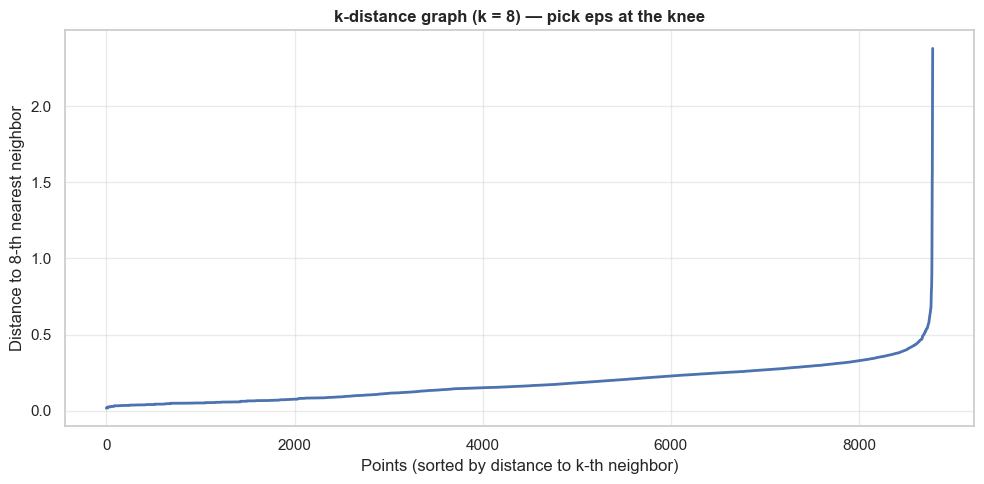

Selected eps = 0.4 (knee location), min_samples = 8.


In [12]:
# Step 1: k-distance graph
MIN_SAMPLES = 8  # standard rule: 2 * dimensions
neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_scaled)
distancias, _ = neigh.kneighbors(X_scaled)
distancias = np.sort(distancias[:, MIN_SAMPLES - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(distancias, linewidth=2)
ax.set_title(f"k-distance graph (k = {MIN_SAMPLES}) — pick eps at the knee",
             fontweight='bold')
ax.set_xlabel("Points (sorted by distance to k-th neighbor)")
ax.set_ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbor")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_kdistance.png', dpi=120)
plt.show()

# Pick eps at the knee. For this dataset, the knee is around 0.4
EPS_OPTIMO = 0.4
print(f"Selected eps = {EPS_OPTIMO} (knee location), min_samples = {MIN_SAMPLES}.")


## 4. DBSCAN with chosen parameters

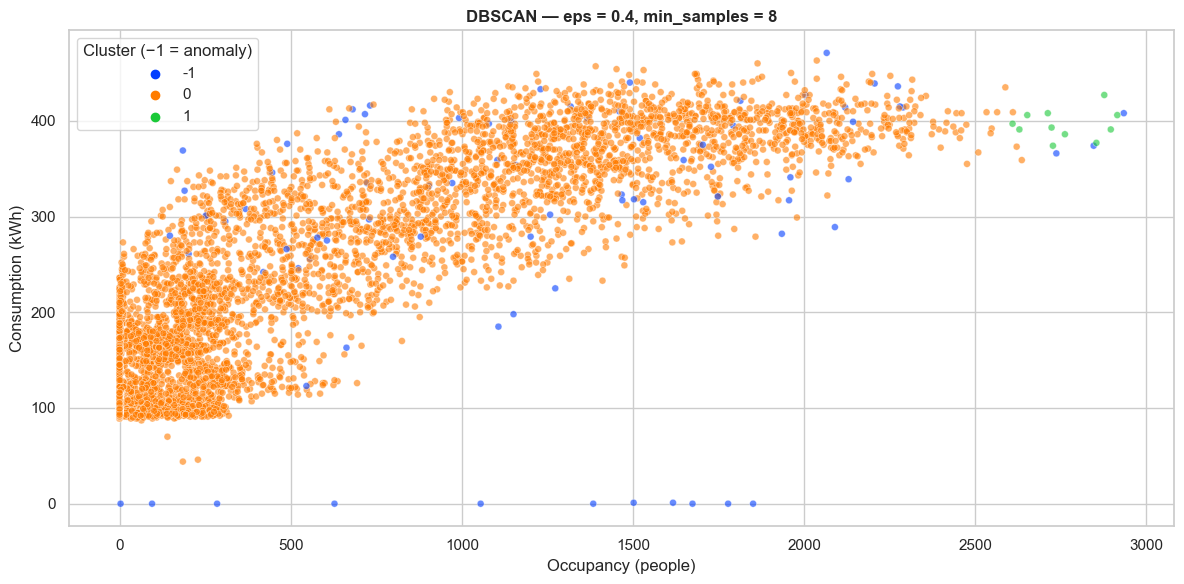


📊 DBSCAN found 2 routine clusters covering 8702 hours.
🚨 DBSCAN flagged 81 hours as anomalies (label −1).


In [ ]:
dbscan = DBSCAN(eps=EPS_OPTIMO, min_samples=MIN_SAMPLES)
df_ml['Perfil_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=df_ml, x='Ocupacion_Simulada', y='Consumo_kWh',
    hue='Perfil_DBSCAN', palette='bright', alpha=0.6, s=25, ax=ax
)
ax.set_title(f"DBSCAN — eps = {EPS_OPTIMO}, min_samples = {MIN_SAMPLES}",
             fontweight='bold')
ax.set_xlabel("Occupancy (people)")
ax.set_ylabel("Consumption (kWh)")
ax.legend(title='Cluster (−1 = anomaly)', loc='best')
plt.tight_layout()
plt.savefig(FIGURES / 'dbscan_clusters.png', dpi=120)
plt.show()

# Counts
n_anomalias = (df_ml['Perfil_DBSCAN'] == -1).sum()
n_rutina = (df_ml['Perfil_DBSCAN'] != -1).sum()
n_clusters = df_ml.loc[df_ml['Perfil_DBSCAN'] != -1, 'Perfil_DBSCAN'].nunique()
print(f"\n📊 DBSCAN found {n_clusters} routine clusters covering {n_rutina} hours.")
print(f"🚨 DBSCAN flagged {n_anomalias} hours as anomalies (label −1).")


In [16]:
display(df_ml['Perfil_DBSCAN'] == -1)

0       False
1       False
2       False
3       False
4       False
        ...  
8778    False
8779    False
8780    False
8781    False
8782    False
Name: Perfil_DBSCAN, Length: 8783, dtype: bool


Cluster composition by calendar day type:
tipo_dia       Altre  Avaluacio  Classe  Dissabte  Diumenge  Festiu  \
Perfil_KMeans                                                         
0               0.07       0.06    0.26      0.22      0.22    0.03   
1               0.03       0.08    0.43      0.16      0.16    0.03   
2               0.02       0.15    0.78      0.00      0.00    0.00   
3               0.51       0.04    0.04      0.19      0.19    0.03   

tipo_dia       La Benvinguda  No lectiu  Vacances  
Perfil_KMeans                                      
0                       0.01       0.02      0.12  
1                       0.01       0.02      0.08  
2                       0.02       0.03      0.00  
3                       0.00       0.00      0.00  


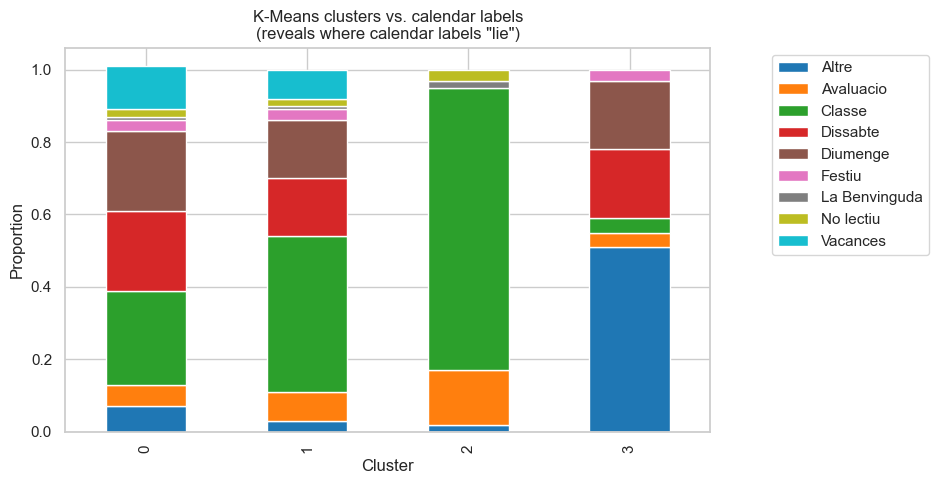

In [14]:
# Añade esto después de la sección 4, antes del save:

## 5. Cross-tab: clusters vs. calendar labels
# ─────────────────────────────────────────────────────────────────────
df_ml['Timestamp'] = pd.to_datetime(df_ml['Timestamp'])
df_ml['fecha'] = df_ml['Timestamp'].dt.date

cal = pd.read_csv('../data/raw/Calendari-UPF-2024.csv')
cal.columns = ['fecha','tipo_dia']
cal['fecha'] = pd.to_datetime(cal['fecha']).dt.date

df_ml = df_ml.merge(cal, on='fecha', how='left')

cross = pd.crosstab(df_ml['Perfil_KMeans'], df_ml['tipo_dia'],
                    normalize='index').round(2)
print("\nCluster composition by calendar day type:")
print(cross)

fig, ax = plt.subplots(figsize=(10, 5))
cross.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('K-Means clusters vs. calendar labels\n'
             '(reveals where calendar labels "lie")')
ax.set_xlabel('Cluster'); ax.set_ylabel('Proportion')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.savefig(FIGURES / 'kmeans_vs_calendar.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Save the labeled dataset for the anomaly notebook

In [15]:
df_ml.to_csv(DATA_PROCESSED / 'df_ml_clustered.csv', index=False)
print(f"✅ Saved clustered dataset to {DATA_PROCESSED / 'df_ml_clustered.csv'}")


✅ Saved clustered dataset to ..\data\processed\df_ml_clustered.csv
